# **MÓDULO 33 - Projeto Final de Modelos Avançados**

**Objetivo do Projeto:**

O objetivo deste projeto é aplicar os conceitos aprendidos nos módulos de conceitos avançados de modelagem para realizar uma segmentação de clientes utilizando o algoritmo de clustering K-Means. Ao final do projeto, você terá a oportunidade de consolidar seus conhecimentos em exploração de dados, pré-processamento, implementação e avaliação de modelos.

**Exploração de Dados:**

Inicie explorando o dataset fornecido, buscando entender as principais características das variáveis e a distribuição dos dados.

Realize análises descritivas, identifique padrões, e verifique a presença de valores ausentes ou inconsistências que precisem ser tratadas.

**Tratamento de Dados:**

Realize os tratamentos necessários como limpeza de dados, normalização ou padronização das variáveis, e, se necessário, a criação de variáveis derivadas.

Documente cada etapa do tratamento, explicando o motivo das escolhas feitas e como elas impactam no modelo.

**Implementação do Algoritmo K-Means:**

Aplique o algoritmo K-Means no dataset tratado. Defina o número de clusters (k).
Execute o algoritmo, ajuste os parâmetros conforme necessário, e documente o processo.

**Avaliação e Interpretação dos Resultados:**

Avalie a qualidade dos clusters gerados utilizando métricas adequadas.

Interprete os resultados, descrevendo as características de cada cluster e como eles podem ser utilizados para a segmentação de clientes.

Sugira aplicações práticas para os clusters identificados, como estratégias de marketing direcionadas ou personalização de ofertas.

**O dataset a ser utilizado neste projeto contém informações de 200 clientes, com os seguintes atributos:**

CustomerID: Identificador único atribuído a cada cliente.

Gender: Gênero do cliente.

Age: Idade do cliente.

Annual Income (k$): Renda anual do cliente em milhares de dólares.

Spending Score (1-100): Pontuação atribuída pelo shopping com base no
comportamento e padrão de gastos do cliente.

Notem que neste projeto vocês terão autonomia para criar os passos e justificar, sempre, os passos escolhidos.

## Solucao do projeto

Abaixo esta um fluxo completo de analise, tratamento, modelagem com K-Means e interpretacao dos grupos. O codigo foi comentado para deixar clara a funcao de cada etapa.

In [1]:
# Importa as bibliotecas usadas em analise, visualizacao e clustering.
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

from sklearn.cluster import KMeans
from sklearn.metrics import silhouette_score
from sklearn.preprocessing import StandardScaler

# Ajusta um estilo padrao para deixar os graficos mais legiveis.
sns.set_theme(style='whitegrid', palette='Set2')
plt.rcParams['figure.figsize'] = (10, 6)

In [2]:
# Le o arquivo CSV com os dados dos clientes.
df = pd.read_csv('Mall_Customers.csv')

# Exibe as primeiras linhas para confirmar a estrutura do dataset.
display(df.head())

# Mostra o tamanho da base e os tipos das colunas.
print(f'Linhas: {df.shape[0]} | Colunas: {df.shape[1]}')
display(df.info())

,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,Male,19,15,39
1,2,Male,21,15,81
2,3,Female,20,16,6
3,4,Female,23,16,77
4,5,Female,31,17,40


Linhas: 200 | Colunas: 5
<class 'pandas.core.frame.DataFrame'>
RangeIndex: 200 entries, 0 to 199
Data columns (total 5 columns):
 #   Column                  Non-Null Count  Dtype 
---  ------                  --------------  ----- 
 0   CustomerID              200 non-null    int64 
 1   Gender                  200 non-null    object
 2   Age                     200 non-null    int64 
 3   Annual Income (k$)      200 non-null    int64 
 4   Spending Score (1-100)  200 non-null    int64 
dtypes: int64(4), object(1)
memory usage: 7.9+ KB


None

## 1. Exploracao inicial

Nesta etapa, verificamos a qualidade da base, o perfil geral dos clientes e possiveis problemas que precisem ser tratados antes do clustering.

In [3]:
# Resume estatisticas descritivas das variaveis numericas.
display(df.describe().T)

# Verifica se ha valores ausentes em alguma coluna.
display(df.isnull().sum().to_frame('valores_ausentes'))

# Verifica a existencia de linhas duplicadas.
print(f'Registros duplicados: {df.duplicated().sum()}')

# Mostra a distribuicao da variavel categorica Gender.
display(df['Gender'].value_counts().to_frame('frequencia'))

,count,mean,std,min,25%,50%,75%,max
CustomerID,200.0,100.50,57.879185,1.0,50.75,100.5,150.25,200.0
Age,200.0,38.85,13.969007,18.0,28.75,36.0,49.00,70.0
Annual Income (k$),200.0,60.56,26.264721,15.0,41.50,61.5,78.00,137.0
Spending Score (1-100),200.0,50.20,25.823522,1.0,34.75,50.0,73.00,99.0


,valores_ausentes
CustomerID,0
Gender,0
Age,0
Annual Income (k$),0
Spending Score (1-100),0


Registros duplicados: 0


,frequencia
Gender,
Female,112
Male,88


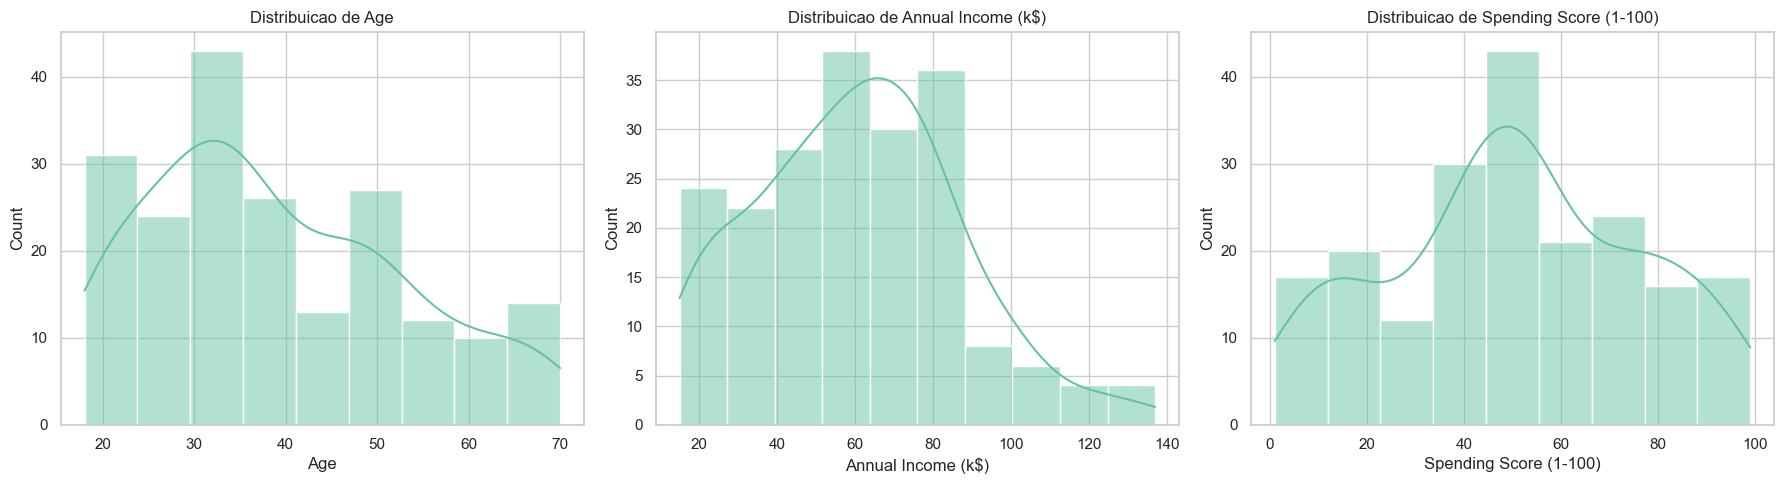

In [4]:
# Cria histogramas para entender a distribuicao das variaveis numericas.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))
colunas_numericas = ['Age', 'Annual Income (k$)', 'Spending Score (1-100)']

for ax, coluna in zip(axes, colunas_numericas):
    sns.histplot(df[coluna], kde=True, ax=ax)
    ax.set_title(f'Distribuicao de {coluna}')

plt.tight_layout()
plt.show()

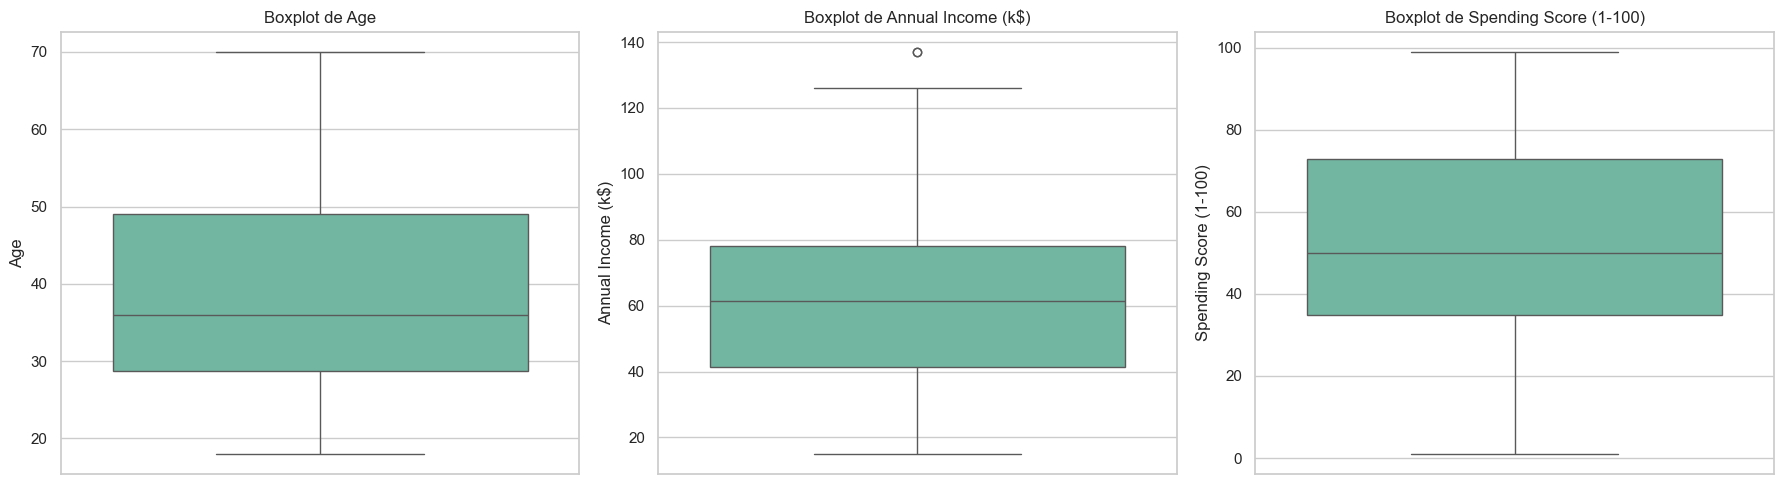

In [5]:
# Cria boxplots para ajudar a identificar outliers visuais.
fig, axes = plt.subplots(1, 3, figsize=(18, 5))

for ax, coluna in zip(axes, colunas_numericas):
    sns.boxplot(y=df[coluna], ax=ax)
    ax.set_title(f'Boxplot de {coluna}')

plt.tight_layout()
plt.show()

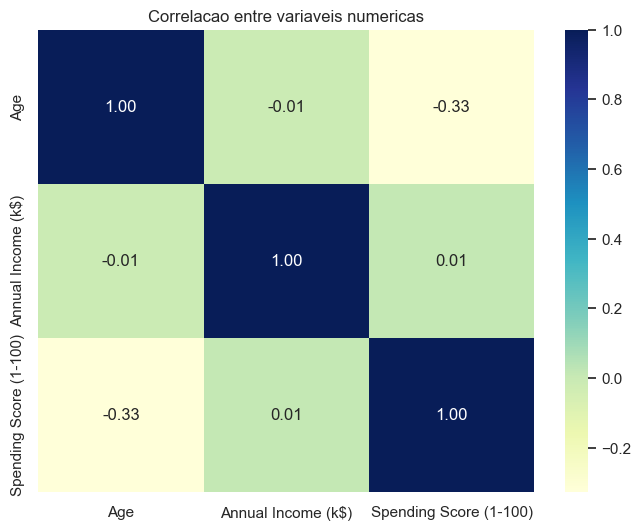

In [6]:
# Gera uma matriz de correlacao para avaliar relacoes entre as variaveis numericas.
plt.figure(figsize=(8, 6))
sns.heatmap(df[colunas_numericas].corr(), annot=True, cmap='YlGnBu', fmt='.2f')
plt.title('Correlacao entre variaveis numericas')
plt.show()

### Conclusoes da exploracao

- `CustomerID` e apenas um identificador e nao deve ser usado na clusterizacao.
- Caso nao existam nulos e duplicatas, a limpeza da base fica simples.
- Como K-Means depende de distancia, faz sentido padronizar as variaveis para evitar que escalas maiores dominem o algoritmo.
- `Gender` pode ser incorporado apos codificacao numerica para enriquecer o perfil dos grupos.

## 2. Tratamento dos dados

Vamos remover o identificador, transformar a coluna categorica em numero e padronizar as variaveis para que todas contribuam de forma equilibrada no calculo das distancias.

In [7]:
# Faz uma copia da base original para preservar os dados crus.
df_tratado = df.copy()

# Remove CustomerID porque ele nao carrega comportamento do cliente.
df_tratado = df_tratado.drop(columns='CustomerID')

# Converte Gender em binario para que a coluna possa entrar no modelo.
df_tratado['Gender'] = df_tratado['Gender'].map({'Female': 0, 'Male': 1})

# Separa as variaveis que serao usadas no clustering.
X = df_tratado.copy()

# Padroniza os dados para media 0 e desvio padrao 1.
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)

# Exibe a base tratada para conferencia.
display(df_tratado.head())

,Gender,Age,Annual Income (k$),Spending Score (1-100)
0,1,19,15,39
1,1,21,15,81
2,0,20,16,6
3,0,23,16,77
4,0,31,17,40


## 3. Escolha do numero de clusters

Para decidir o melhor valor de `k`, usamos dois criterios complementares:

- Metodo do cotovelo: observa a reducao da inercia.
- Silhouette Score: mede a separacao e coesao dos grupos.

In [8]:
# Testa varios valores de k e armazena as metricas para comparacao.
valores_k = range(2, 11)
inercias = []
silhuetas = []

for k in valores_k:
    modelo_kmeans = KMeans(n_clusters=k, random_state=42, n_init=10)
    labels = modelo_kmeans.fit_predict(X_scaled)
    
    # Inercia mede a soma das distancias internas aos clusters.
    inercias.append(modelo_kmeans.inertia_)
    
    # Silhueta mede o quao bem cada ponto esta alocado no proprio grupo.
    silhuetas.append(silhouette_score(X_scaled, labels))

metricas_k = pd.DataFrame({
    'k': list(valores_k),
    'inercia': inercias,
    'silhouette': silhuetas
})

display(metricas_k)

,k,inercia,silhouette
0,2,588.802677,0.251815
1,3,476.787554,0.259513
2,4,388.717861,0.298397
3,5,331.309884,0.304060
4,6,276.411760,0.331074
5,7,236.204947,0.357377
6,8,199.750461,0.387993
7,9,174.235477,0.403092
8,10,152.029834,0.420764


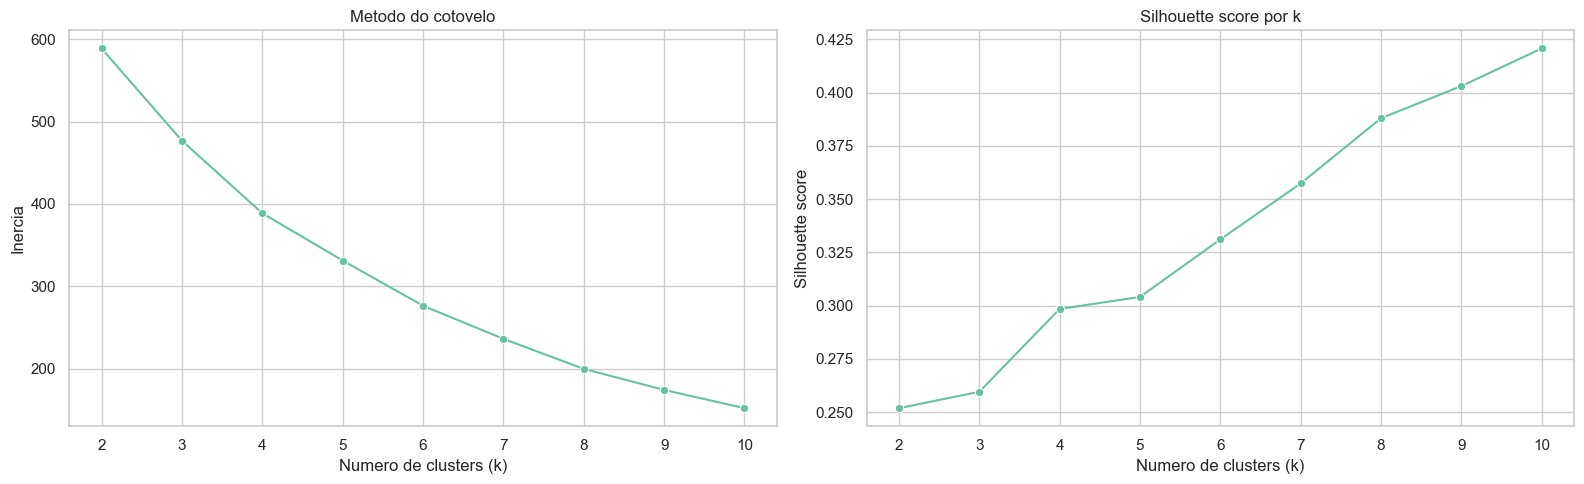

In [9]:
# Plota as curvas para apoiar a escolha do melhor k.
fig, axes = plt.subplots(1, 2, figsize=(16, 5))

sns.lineplot(data=metricas_k, x='k', y='inercia', marker='o', ax=axes[0])
axes[0].set_title('Metodo do cotovelo')
axes[0].set_xlabel('Numero de clusters (k)')
axes[0].set_ylabel('Inercia')

sns.lineplot(data=metricas_k, x='k', y='silhouette', marker='o', ax=axes[1])
axes[1].set_title('Silhouette score por k')
axes[1].set_xlabel('Numero de clusters (k)')
axes[1].set_ylabel('Silhouette score')

plt.tight_layout()
plt.show()

In [10]:
# Seleciona automaticamente o k com melhor silhouette score.
melhor_k = int(metricas_k.loc[metricas_k['silhouette'].idxmax(), 'k'])
print(f'Melhor k segundo a silhouette: {melhor_k}')

Melhor k segundo a silhouette: 10


## 4. Treinamento do modelo final

Com o valor de `k` escolhido, treinamos o K-Means final e adicionamos o rotulo do cluster a base original para facilitar a interpretacao.

In [11]:
# Treina o modelo final com o numero de clusters escolhido.
modelo_final = KMeans(n_clusters=melhor_k, random_state=42, n_init=10)
clusters = modelo_final.fit_predict(X_scaled)

# Adiciona o cluster a base original para analise de negocio.
df_resultado = df.copy()
df_resultado['Cluster'] = clusters

# Calcula a silhouette do modelo final como medida de qualidade.
silhouette_final = silhouette_score(X_scaled, clusters)
print(f'Silhouette score do modelo final: {silhouette_final:.4f}')

display(df_resultado.head())

Silhouette score do modelo final: 0.4208


,CustomerID,Gender,Age,Annual Income (k$),Spending Score (1-100),Cluster
0,1,Male,19,15,39,1
1,2,Male,21,15,81,1
2,3,Female,20,16,6,2
3,4,Female,23,16,77,8
4,5,Female,31,17,40,2


In [12]:
# Resume o tamanho de cada cluster.
display(df_resultado['Cluster'].value_counts().sort_index().to_frame('quantidade_clientes'))

,quantidade_clientes
Cluster,
0,26
1,24
2,14
3,21
4,26
5,19
6,25
7,18
8,13


In [13]:
# Cria um perfil medio dos clusters para apoiar a interpretacao.
perfil_clusters = (
    df_resultado
    .groupby('Cluster')
    .agg({
        'Age': ['mean', 'median'],
        'Annual Income (k$)': ['mean', 'median'],
        'Spending Score (1-100)': ['mean', 'median'],
        'CustomerID': 'count'
    })
)

perfil_clusters.columns = ['_'.join(col).strip() for col in perfil_clusters.columns]
perfil_clusters = perfil_clusters.rename(columns={'CustomerID_count': 'quantidade_clientes'})
display(perfil_clusters.round(2))

,Age_mean,Age_median,Annual Income (k$)_mean,Annual Income (k$)_median,Spending Score (1-100)_mean,Spending Score (1-100)_median,quantidade_clientes
Cluster,,,,,,,
0,58.85,59.0,48.69,51.5,39.85,46.0,26
1,25.25,24.0,41.25,44.0,60.92,57.5,24
2,41.21,41.0,26.07,26.5,20.14,16.0,14
3,32.19,32.0,86.05,79.0,81.67,83.0,21
4,54.15,50.5,54.23,54.0,48.96,49.5,26
5,38.47,40.0,85.89,81.0,14.21,13.0,19
6,27.96,27.0,57.36,60.0,47.12,47.0,25
7,33.28,32.0,87.11,82.5,82.67,85.5,18
8,25.46,23.0,25.69,23.0,80.54,77.0,13


In [14]:
# Mostra o genero predominante em cada grupo para complementar o perfil.
genero_cluster = (
    df_resultado
    .groupby('Cluster')['Gender']
    .agg(lambda serie: serie.mode().iat[0])
    .to_frame('genero_predominante')
)

display(genero_cluster)

,genero_predominante
Cluster,
0,Male
1,Male
2,Female
3,Female
4,Female
5,Male
6,Female
7,Male
8,Female


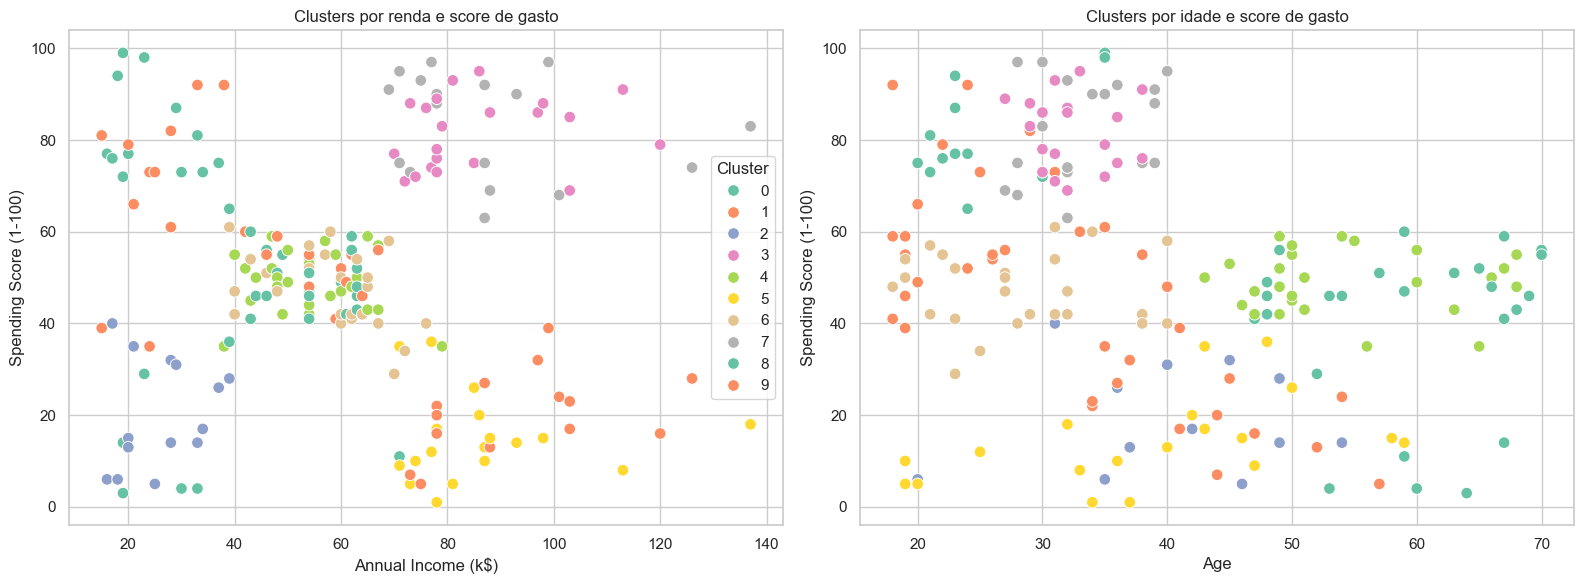

In [15]:
# Gera graficos para visualizar os grupos em duas dimensoes importantes para negocio.
fig, axes = plt.subplots(1, 2, figsize=(16, 6))

sns.scatterplot(
    data=df_resultado,
    x='Annual Income (k$)',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=70,
    ax=axes[0]
)
axes[0].set_title('Clusters por renda e score de gasto')

sns.scatterplot(
    data=df_resultado,
    x='Age',
    y='Spending Score (1-100)',
    hue='Cluster',
    palette='Set2',
    s=70,
    ax=axes[1],
    legend=False
)
axes[1].set_title('Clusters por idade e score de gasto')

plt.tight_layout()
plt.show()

## 5. Interpretacao dos resultados

Use a tabela `perfil_clusters` para descrever cada grupo encontrado. Um roteiro simples para a interpretacao e:

- clusters com alta renda e alto spending score: clientes premium, bons candidatos a campanhas exclusivas;
- clusters com alta renda e baixo spending score: clientes com potencial de conversao, que podem responder a beneficios e personalizacao;
- clusters com baixa renda e alto spending score: clientes engajados e sensiveis a promocoes;
- clusters com baixa renda e baixo spending score: publico de menor prioridade comercial;
- clusters com idade mais elevada ou mais jovem: podem receber comunicacoes adaptadas ao perfil etario.

In [16]:
# Monta uma versao final da tabela de apoio para a conclusao do trabalho.
resumo_final = perfil_clusters.join(genero_cluster)
display(resumo_final.round(2))

,Age_mean,Age_median,Annual Income (k$)_mean,Annual Income (k$)_median,Spending Score (1-100)_mean,Spending Score (1-100)_median,quantidade_clientes,genero_predominante
Cluster,,,,,,,,
0,58.85,59.0,48.69,51.5,39.85,46.0,26,Male
1,25.25,24.0,41.25,44.0,60.92,57.5,24,Male
2,41.21,41.0,26.07,26.5,20.14,16.0,14,Female
3,32.19,32.0,86.05,79.0,81.67,83.0,21,Female
4,54.15,50.5,54.23,54.0,48.96,49.5,26,Female
5,38.47,40.0,85.89,81.0,14.21,13.0,19,Male
6,27.96,27.0,57.36,60.0,47.12,47.0,25,Female
7,33.28,32.0,87.11,82.5,82.67,85.5,18,Male
8,25.46,23.0,25.69,23.0,80.54,77.0,13,Female
